In [122]:
# from RRAM import Montecarlo as mc
import pandas as pd
import matplotlib.pyplot as plt

In [123]:
import pandas as pd
import matplotlib.pyplot as plt


def Plot_2panel(data_path: str, col_indices_x: list, col_indices_y: list, global_tittle: str = None,
                titles: list = None, eje_x: list = None, eje_y: list = None, log_scale: list = [None, None]) -> None:

    # Leer los datos desde el CSV
    data = pd.read_csv(data_path)

    for i, column in enumerate(data.columns):
        print(f"Columna {i}: {column}")

    print("\n")
    x1, x2 = data.iloc[:, col_indices_x[0]], data.iloc[:, col_indices_x[1]]
    y1, y2 = data.iloc[:, col_indices_y[0]], data.iloc[:, col_indices_y[1]]

    # Imprimir los nombres de las columnas
    print("x1 pertenece a la columna:", data.columns[col_indices_x[0]])
    print("y1 pertenece a la columna:", data.columns[col_indices_y[0]])
    print("x2 pertenece a la columna:", data.columns[col_indices_x[1]])
    print("y2 pertenece a la columna:", data.columns[col_indices_y[1]])

    # Crear la figura y los subplots
    fig, axes = plt.subplots(2, 1, figsize=(6, 6))

    # Asignar datos y títulos/etiquetas si se proporcionan
    for i, (ax, x, y) in enumerate(zip(axes, [x1, x2], [y1, y2])):
        ax.scatter(x, y, s=5)
        if titles and len(titles) > i:
            ax.set_title(titles[i])
        if eje_x and len(eje_x) > i:
            ax.set_xlabel(eje_x[i])
        else:
            ax.set_xlabel(data.columns[col_indices_x[i]])
        if eje_y and len(eje_y) > i:
            ax.set_ylabel(eje_y[i])
        else:
            ax.set_ylabel(data.columns[col_indices_y[i]])
        if log_scale and len(log_scale) > i:
            if log_scale[i] == 'x':
                ax.set_xscale('log')
            elif log_scale[i] == 'y':
                ax.set_yscale('log')
            elif log_scale[i] == 'both':
                ax.set_xscale('log')
                ax.set_yscale('log')

    # Título general
    if global_tittle:
        fig.suptitle(global_tittle, fontsize=16)
        fig.subplots_adjust(top=0.88)

    # Ajustar diseño y guardar la figura
    fig.tight_layout()

    # Guardo la figura
    if global_tittle is not None:
        partes = global_tittle.split(',')
        filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}_{partes[0].split('=')[1].strip()}-{partes[1].split('=')[1].strip()}.png"
    else:
        filename = f"Results/Panel_{data_path.split('/')[-1].split('.')[0]}.png"

    plt.savefig(f"{filename}.png")
    plt.show()

Columna 0:  tiempo simulacion
Columna 1:  voltaje
Columna 2:  velocidad
Columna 3:  desplazamiento
Columna 4:  prob generacion
Columna 5:  prob recombinacion
Columna 6:  vancantes generadas
Columna 7:  vacantes totales
Columna 8:  intensidad
Columna 9:  temperatura


x1 pertenece a la columna:  voltaje
y1 pertenece a la columna:  intensidad
x2 pertenece a la columna:  tiempo simulacion
y2 pertenece a la columna:  temperatura


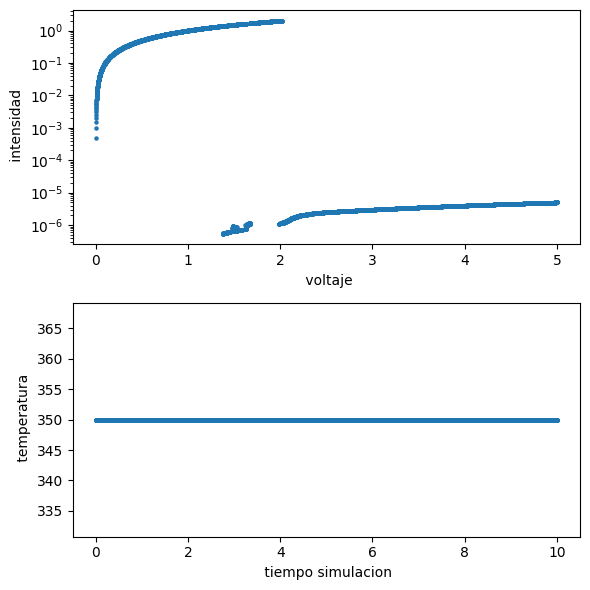

In [124]:
Plot_2panel(data_path=f'Results/resultados_0.csv',
            col_indices_x=[1, 0],
            col_indices_y=[8, 9],
            global_tittle=None,  # fr'$\gamma^{{drift}} = 9$, $E_m = 0.9$ eV pruebas de intensidad',
            # titles=['Temperatura', 'Intensidad'],
            log_scale=['y', None])